In [1]:
import matplotlib.pyplot as plt
import numpy as np

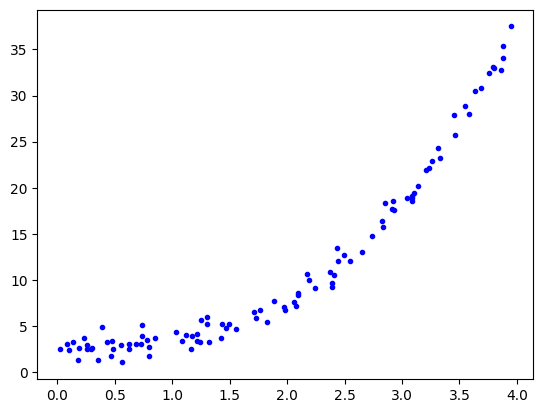

In [ ]:
np.random.seed(42)
m = 100
X = 4 * np.random.rand(m, 1)
#   w0  w1         w2
y = 2 + 1.0 * X+ 0.5 * X*X *X+ np.random.randn(m, 1)
plt.plot(X, y, "b.", linewidth=3)

In [20]:
unos=np.ones((m,1))
A=np.hstack((unos,X,X*X*X))
b=y
    
lr=0.0001
w=np.zeros((3,1))
mse=[]
for i in range(10000):
    Aw=np.matmul(A,w)
    Aw_bt=np.transpose(Aw-b)
    grad=2*np.matmul(Aw_bt,A)/m
    w=w-lr*np.transpose(grad)
    print(i,w)
    ye=w[0]+w[1]*X+w[2]*X*X*X
    error=(ye-y)**2
    mse.append(float(error.sum()))


0 [[0.00225064]
 [0.00641133]
 [0.06847113]]
1 [[0.00429647]
 [0.01217133]
 [0.12956429]]
2 [[0.00615953]
 [0.01735011]
 [0.184074  ]]
3 [[0.0078595 ]
 [0.02201027]
 [0.23270922]]
4 [[0.00941393]
 [0.02620763]
 [0.27610255]]
5 [[0.01083848]
 [0.02999202]
 [0.31481849]]
6 [[0.01214714]
 [0.03340792]
 [0.34936073]]
7 [[0.01335237]
 [0.03649497]
 [0.38017872]]
8 [[0.01446531]
 [0.0392886 ]
 [0.40767352]]
9 [[0.01549587]
 [0.04182039]
 [0.43220299]]
10 [[0.01645294]
 [0.04411852]
 [0.45408647]]
11 [[0.0173444 ]
 [0.04620814]
 [0.4736089 ]]
12 [[0.01817731]
 [0.0481117 ]
 [0.49102454]]
13 [[0.01895798]
 [0.04984923]
 [0.50656025]]
14 [[0.01969202]
 [0.05143858]
 [0.52041848]]
15 [[0.02038444]
 [0.05289572]
 [0.53277989]]
16 [[0.02103971]
 [0.05423487]
 [0.54380565]]
17 [[0.02166183]
 [0.05546872]
 [0.55363961]]
18 [[0.02225436]
 [0.05660859]
 [0.5624101 ]]
19 [[0.02282047]
 [0.05766461]
 [0.57023165]]
20 [[0.023363  ]
 [0.05864579]
 [0.57720645]]
21 [[0.02388448]
 [0.05956018]
 [0.58342569]

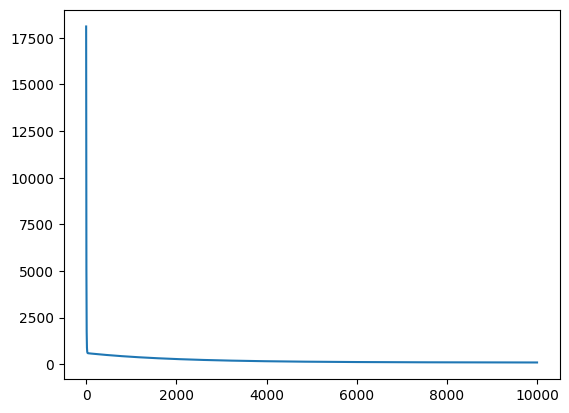

In [21]:
plt.plot(mse)
plt.show()

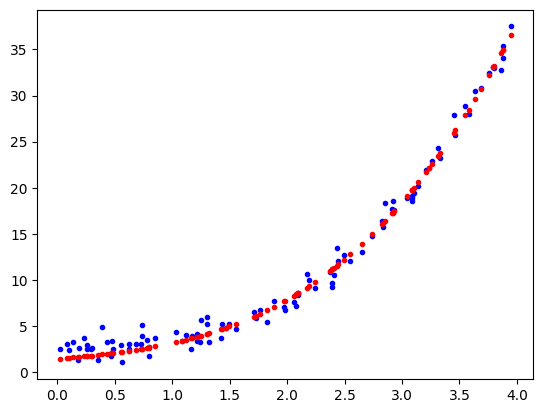

In [22]:
plt.plot(X, y, "b.", linewidth=3)
plt.plot(X, ye, "r.", linewidth=3)

In [24]:
from sklearn.linear_model import SGDRegressor


In [ ]:
!pip install scikit-learn

In [35]:
sgd= SGDRegressor(eta0=0.0001)
sgd.fit(np.hstack((X,X*X*X)), y)


h:\Anaconda\envs\deepf\lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,loss,'squared_error'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,random_state,None


In [36]:
print(sgd.intercept_,sgd.coef_)

[0.73634565] [0.77257045 0.55285229]


In [ ]:
X_new=np.linspace(0,4,100).reshape(-1,1)
print(np.shape(X_new))
XX_new=np.hstack((X_new,X_new*X_new*X_new))
ypred=sgd.predict(XX_new)


(100, 1)


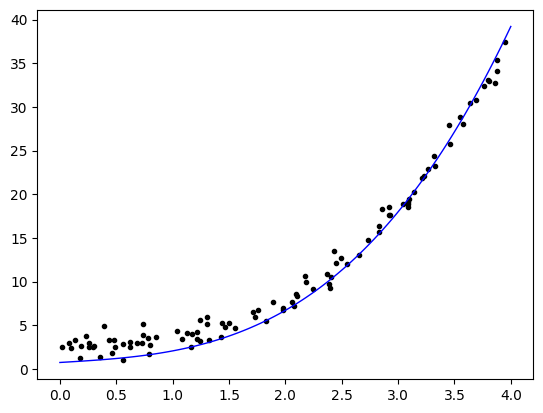

In [38]:
plt.plot(X, y, "k.", linewidth=3)
plt.plot(X_new, ypred, "b-", linewidth=1)
